# Comparing models for RAM and CPU metric forecasting
The 3 selected models for comparison are:
- Facebook Prophet &rarr; Represents statistical models (ARIMA/SARIMA, ETS, Prophet, ...)
- N-HiTS &rarr; Represents deep learning models (LSTM, TFT, N-HiTS, ...)
- Amazon Chronos &rarr; Represents LLM-based models (Chronos, TimeGPT, ...)

## Data

Data was collected from the Bitbrain datacenter dataset, provided by a service provider focused on managed hosting and computing for businesses. The dataset contains information for 1250 VMs; one VM was selected for the model comparison.
Original dataset: https://www.kaggle.com/datasets/gauravdhamane/gwa-bitbrains

The dataset contains 3 columns: Timestamp, CPU Usage(%), and RAM Usage(%). It has been preprocessed from the original data.

In [3]:
import pandas as pd
import numpy as np
original_df = pd.read_csv("collected_metrics.csv")
original_df['Timestamp'] = pd.to_datetime(original_df['Timestamp'], unit='ms')

print(original_df.head())
print("="*50)
print(original_df.info())

            Timestamp  Memory Usage  CPU Usage
0 2026-04-20 17:00:00     42.282991  11.566667
1 2026-04-20 17:00:15     42.291728  13.033333
2 2026-04-20 17:00:30     42.086092  12.533333
3 2026-04-20 17:00:45     42.024457  11.700000
4 2026-04-20 17:01:00     42.196733  13.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31675 entries, 0 to 31674
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Timestamp     31675 non-null  datetime64[ns]
 1   Memory Usage  31675 non-null  float64       
 2   CPU Usage     31675 non-null  float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 742.5 KB
None


In [4]:
train_df = original_df.iloc[:-300]
test_df = original_df.iloc[-300:]

print(train_df)
print("="*50)
print(test_df)

                Timestamp  Memory Usage  CPU Usage
0     2026-04-20 17:00:00     42.282991  11.566667
1     2026-04-20 17:00:15     42.291728  13.033333
2     2026-04-20 17:00:30     42.086092  12.533333
3     2026-04-20 17:00:45     42.024457  11.700000
4     2026-04-20 17:01:00     42.196733  13.000000
...                   ...           ...        ...
31370 2026-04-26 03:42:30     60.191783  15.900000
31371 2026-04-26 03:42:45     60.053899  14.966667
31372 2026-04-26 03:43:00     60.014265  13.633333
31373 2026-04-26 03:43:15     60.211084  14.866667
31374 2026-04-26 03:43:30     60.210131  15.066667

[31375 rows x 3 columns]
                Timestamp  Memory Usage  CPU Usage
31375 2026-04-26 03:43:45     60.288684  14.466667
31376 2026-04-26 03:44:00     60.298612  13.666667
31377 2026-04-26 03:44:15     60.207907  15.800000
31378 2026-04-26 03:44:30     60.356832  15.433333
31379 2026-04-26 03:44:45     60.254372  15.600000
...                   ...           ...        ...
31670

## Facebook Prophet

In [5]:
from prophet import Prophet

/home/nguyentan/OpenstackDRS/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
prophet_cpu_train_df = pd.DataFrame({
    'ds': train_df['Timestamp'],
    'y': train_df['CPU Usage']
})

prophet_memory_train_df = pd.DataFrame({
    'ds': train_df['Timestamp'],
    'y': train_df['Memory Usage']
})

print("--- CPU Train DF ---")
print(prophet_cpu_train_df.head())
print("\n--- Memory Train DF ---")
print(prophet_memory_train_df.head())

--- CPU Train DF ---
                   ds          y
0 2026-04-20 17:00:00  11.566667
1 2026-04-20 17:00:15  13.033333
2 2026-04-20 17:00:30  12.533333
3 2026-04-20 17:00:45  11.700000
4 2026-04-20 17:01:00  13.000000

--- Memory Train DF ---
                   ds          y
0 2026-04-20 17:00:00  42.282991
1 2026-04-20 17:00:15  42.291728
2 2026-04-20 17:00:30  42.086092
3 2026-04-20 17:00:45  42.024457
4 2026-04-20 17:01:00  42.196733


In [7]:
prophet_model_cpu = Prophet()
prophet_model_cpu.fit(prophet_cpu_train_df)

prophet_model_memory = Prophet()
prophet_model_memory.fit(prophet_memory_train_df)

13:41:47 - cmdstanpy - INFO - Chain [1] start processing
13:41:56 - cmdstanpy - INFO - Chain [1] done processing
13:41:57 - cmdstanpy - INFO - Chain [1] start processing
13:42:15 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
future_cpu = prophet_model_cpu.make_future_dataframe(periods=300, freq="15s")
forecast_cpu = prophet_model_cpu.predict(future_cpu)
forecast_cpu[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
31670,2026-04-26 04:57:30,15.638526,9.011431,22.859578
31671,2026-04-26 04:57:45,15.640833,8.694817,22.809726
31672,2026-04-26 04:58:00,15.643144,8.298108,22.817783
31673,2026-04-26 04:58:15,15.645457,8.672203,22.444960
31674,2026-04-26 04:58:30,15.647772,8.305312,21.928108


In [9]:
future_memory = prophet_model_memory.make_future_dataframe(periods=300, freq="15s")
forecast_memory = prophet_model_memory.predict(future_memory)
forecast_memory[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
31670,2026-04-26 04:57:30,60.864973,59.106127,62.707680
31671,2026-04-26 04:57:45,60.862851,59.122251,62.676569
31672,2026-04-26 04:58:00,60.860728,59.004477,62.683598
31673,2026-04-26 04:58:15,60.858603,59.190225,62.669866
31674,2026-04-26 04:58:30,60.856477,59.120111,62.628780


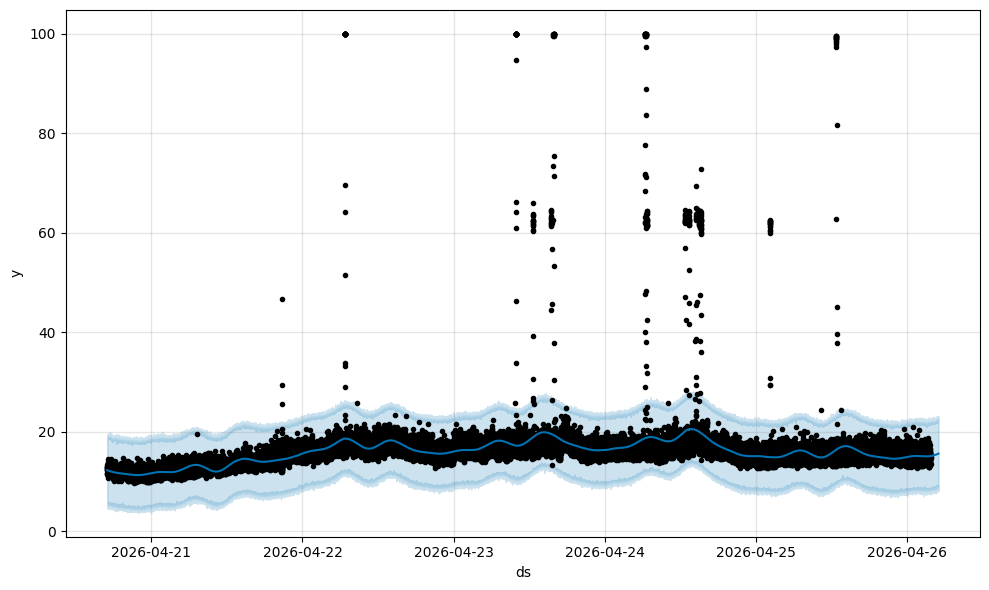

In [10]:
fig1 = prophet_model_cpu.plot(forecast_cpu)

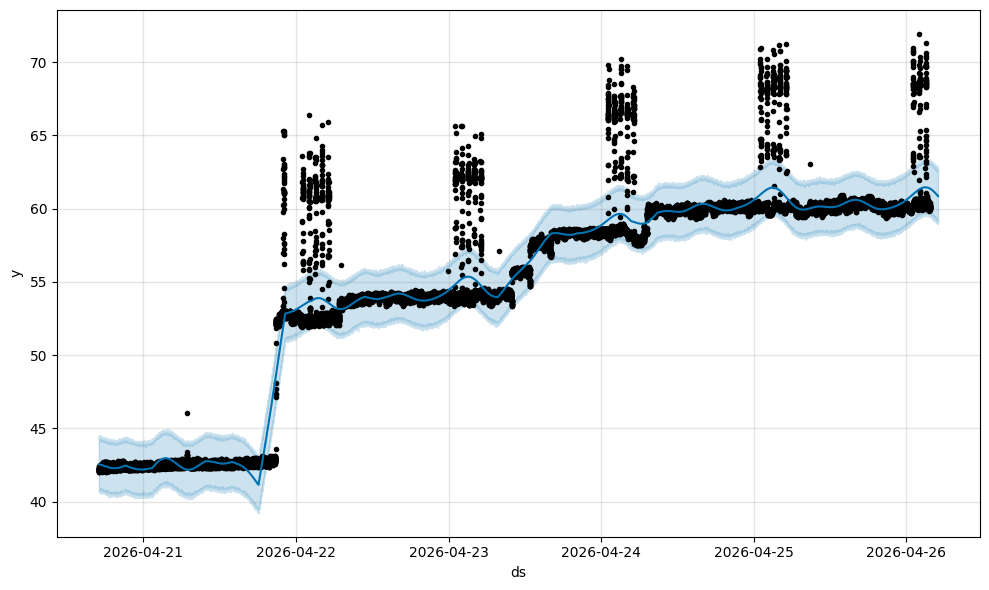

In [11]:
fig2 = prophet_model_memory.plot(forecast_memory)

## N-HiTS

In [12]:
import pandas as pd
import numpy as np
import lightning.pytorch as pl

from sklearn.preprocessing import StandardScaler
from pytorch_forecasting import TimeSeriesDataSet, NHiTS
from pytorch_forecasting.metrics import RMSE

import matplotlib.pyplot as plt

Prepare data

In [13]:
nhits_df = train_df.copy()

nhits_df["time_idx"] = np.arange(len(nhits_df))

# group
nhits_df["group"] = 0

# scale for each metric
scaler_cpu = StandardScaler()
scaler_mem = StandardScaler()

nhits_df["CPU Usage"] = scaler_cpu.fit_transform(nhits_df[["CPU Usage"]])
nhits_df["Memory Usage"] = scaler_mem.fit_transform(nhits_df[["Memory Usage"]])

In [14]:
max_encoder_length = 128
max_prediction_length = 300

training_cutoff = nhits_df["time_idx"].max() - max_prediction_length

In [15]:
cpu_train_ds = TimeSeriesDataSet(
    nhits_df[nhits_df.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="CPU Usage",
    group_ids=["group"],

    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,

    time_varying_unknown_reals=["CPU Usage", "Memory Usage"],
)

cpu_val_ds = TimeSeriesDataSet.from_dataset(
    cpu_train_ds, nhits_df, predict=True, stop_randomization=True
)

In [16]:
mem_train_ds = TimeSeriesDataSet(
    nhits_df[nhits_df.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="Memory Usage",
    group_ids=["group"],

    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,

    time_varying_unknown_reals=["CPU Usage", "Memory Usage"],
)

mem_val_ds = TimeSeriesDataSet.from_dataset(
    mem_train_ds, nhits_df, predict=True, stop_randomization=True
)

In [17]:
cpu_train_loader = cpu_train_ds.to_dataloader(train=True, batch_size=64)
cpu_val_loader = cpu_val_ds.to_dataloader(train=False, batch_size=64)

mem_train_loader = mem_train_ds.to_dataloader(train=True, batch_size=64)
mem_val_loader = mem_val_ds.to_dataloader(train=False, batch_size=64)

In [18]:
cpu_model = NHiTS.from_dataset(
    cpu_train_ds,
    learning_rate=1e-3,
    hidden_size=128,
    dropout=0.1,
    loss=RMSE(),
)

mem_model = NHiTS.from_dataset(
    mem_train_ds,
    learning_rate=1e-3,
    hidden_size=128,
    dropout=0.1,
    loss=RMSE(),
)

/home/nguyentan/OpenstackDRS/venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/home/nguyentan/OpenstackDRS/venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [19]:
trainer = pl.Trainer(
    max_epochs=30,
    gradient_clip_val=0.1,
)

# train CPU
trainer.fit(cpu_model, cpu_train_loader, cpu_val_loader)

# train Memory
trainer.fit(mem_model, mem_train_loader, mem_val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type           | Params | Mode 
-----------------------------------------------------------
0 | loss            | RMSE           | 0      | train
1 | logging_metrics | ModuleList     | 0      | train
2 | embeddings      | MultiEmbedding | 0      | train
3 | model           | NHiTS          | 205 K  | train
-----------------------------------------------------------
205 K     Trainable params
0         Non-trainable params
205 K     Total params
0.822     Total estimated model params size (MB)
44        Modules in train mode
0         Modules in eval mode


Sanity Checking DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]

/home/nguyentan/OpenstackDRS/venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=2` in the `DataLoader` to improve performance.


/home/nguyentan/OpenstackDRS/venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=2` in the `DataLoader` to improve performance.


Epoch 29: 100%|██████████| 478/478 [00:24<00:00, 19.28it/s, v_num=6, train_loss_step=1.180, val_loss=0.213, train_loss_epoch=0.942]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 478/478 [00:24<00:00, 19.26it/s, v_num=6, train_loss_step=1.180, val_loss=0.213, train_loss_epoch=0.942]


/home/nguyentan/OpenstackDRS/venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:751: Checkpoint directory /home/nguyentan/OpenstackDRS/app/predictor/lightning_logs/version_6/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type           | Params | Mode 
-----------------------------------------------------------
0 | loss            | RMSE           | 0      | train
1 | logging_metrics | ModuleList     | 0      | train
2 | embeddings      | MultiEmbedding | 0      | train
3 | model           | NHiTS          | 205 K  | train
-----------------------------------------------------------
205 K     Trainable params
0         Non-trainable params
205 K     Total params
0.822     Total estimated model params size (MB)
44        Modules in train mode
0         Modules in eval mode


`Trainer.fit` stopped: `max_epochs=30` reached.


In [20]:
cpu_preds = cpu_model.predict(cpu_val_loader)
mem_preds = mem_model.predict(mem_val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/nguyentan/OpenstackDRS/venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=2` in the `DataLoader` to improve performance.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [21]:
cpu_preds = scaler_cpu.inverse_transform(cpu_preds.numpy())
mem_preds = scaler_mem.inverse_transform(mem_preds.numpy())

cpu_preds = cpu_preds[0]
mem_preds = mem_preds[0]

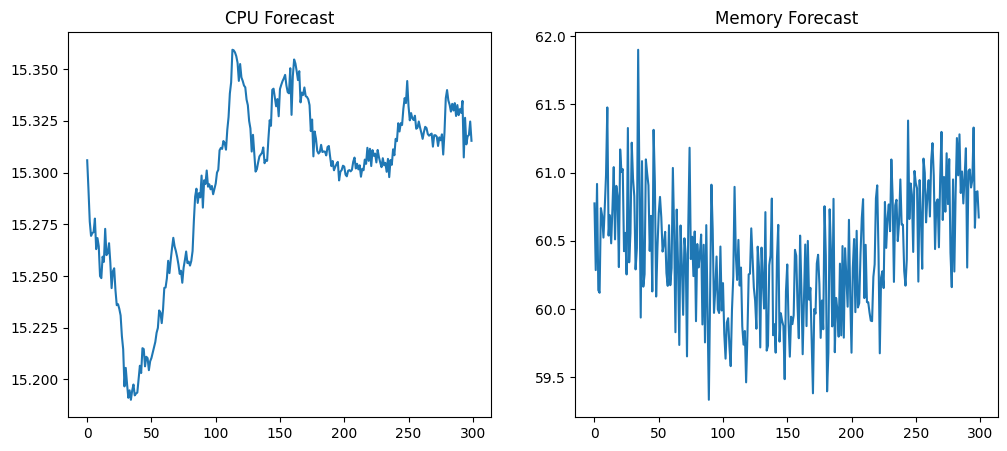

In [22]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(cpu_preds)
plt.title("CPU Forecast")

plt.subplot(1,2,2)
plt.plot(mem_preds)
plt.title("Memory Forecast")

plt.show()

## Amazon Chronos

In [23]:
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

predictor = TimeSeriesPredictor.load("AutogluonModels/ag-20260509_174426/")

print(predictor.model_names())
print(predictor.leaderboard())

['Chronos2ZeroShot', 'Chronos2FineTuned']
               model  score_val  pred_time_val  fit_time_marginal  fit_order
0  Chronos2FineTuned  -3.587635       2.748711        3244.907173          2
1   Chronos2ZeroShot  -3.627033       2.315556          11.585644          1


In [24]:
chronos_df = (
    train_df
    .melt(
        id_vars='Timestamp',
        value_vars=['CPU Usage', 'Memory Usage'],
        var_name='item_id',
        value_name='target'
    )
    .rename(columns={'Timestamp': 'timestamp'})
)

chronos_df['item_id'] = chronos_df['item_id'].map({
    'CPU Usage': 'CPU',
    'Memory Usage': 'Memory'
})

chronos_cpu_df = chronos_df.query("item_id == 'CPU'").reset_index(drop=True)
chronos_memory_df = chronos_df.query("item_id == 'Memory'").reset_index(drop=True)

cpu_train_data = TimeSeriesDataFrame.from_data_frame(
    chronos_cpu_df,
    id_column="item_id",
    timestamp_column="timestamp"
)

mem_train_data = TimeSeriesDataFrame.from_data_frame(
    chronos_memory_df,
    id_column="item_id",
    timestamp_column="timestamp"
)

In [25]:
finetuned_chronos_mem_pred = predictor.predict(mem_train_data[-600:], model="Chronos2FineTuned")
zeroshot_chronos_mem_pred = predictor.predict(mem_train_data[-600:], model="Chronos2ZeroShot")

finetuned_chronos_cpu_pred = predictor.predict(cpu_train_data[-600:], model="Chronos2FineTuned")
zeroshot_chronos_cpu_pred = predictor.predict(cpu_train_data[-600:], model="Chronos2ZeroShot")

## Comparison

### Accuracy evaluation
Selected metrics: RMSE, MASE

In [26]:
# RMSE
def rmse(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

# MASE
def mase(y_train, y_true, y_pred, seasonality=24):
    y_train = np.array(y_train)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Naive forecast error (denominator)
    naive_forecast = np.abs(y_train[seasonality:] - y_train[:-seasonality])
    scale = np.mean(naive_forecast)
    
    # Model error (numerator)
    errors = np.abs(y_true - y_pred)
    
    return np.mean(errors) / scale

For Memory

In [27]:
y_train_mem = train_df['Memory Usage']
y_true_mem = test_df['Memory Usage']
y_pred_prophet_mem = forecast_memory['yhat'].iloc[-300:]
y_pred_nhits_mem = mem_preds
y_pred_finetuned_chronos_mem = finetuned_chronos_mem_pred['mean']
y_pred_zeroshot_chronos_mem = zeroshot_chronos_mem_pred['mean']

In [28]:
eval_mem = pd.DataFrame({
    'Model': ['Prophet', 'N-HiTS', 'ZeroShot_Chronos', 'FineTuned_Chronos'],
    'RMSE': [
        rmse(y_true_mem, y_pred_prophet_mem),
        rmse(y_true_mem, y_pred_nhits_mem),
        rmse(y_true_mem, y_pred_zeroshot_chronos_mem),
        rmse(y_true_mem, y_pred_finetuned_chronos_mem)
    ],
    'MASE': [
        mase(y_train_mem, y_true_mem, y_pred_prophet_mem),
        mase(y_train_mem, y_true_mem, y_pred_nhits_mem),
        mase(y_train_mem, y_true_mem, y_pred_zeroshot_chronos_mem),
        mase(y_train_mem, y_true_mem, y_pred_finetuned_chronos_mem),
    ]
})

display(eval_mem)

,Model,RMSE,MASE
0,Prophet,2.416960,3.177098
1,N-HiTS,2.671221,2.716171
2,ZeroShot_Chronos,0.915059,0.734627
3,FineTuned_Chronos,0.913005,0.734473


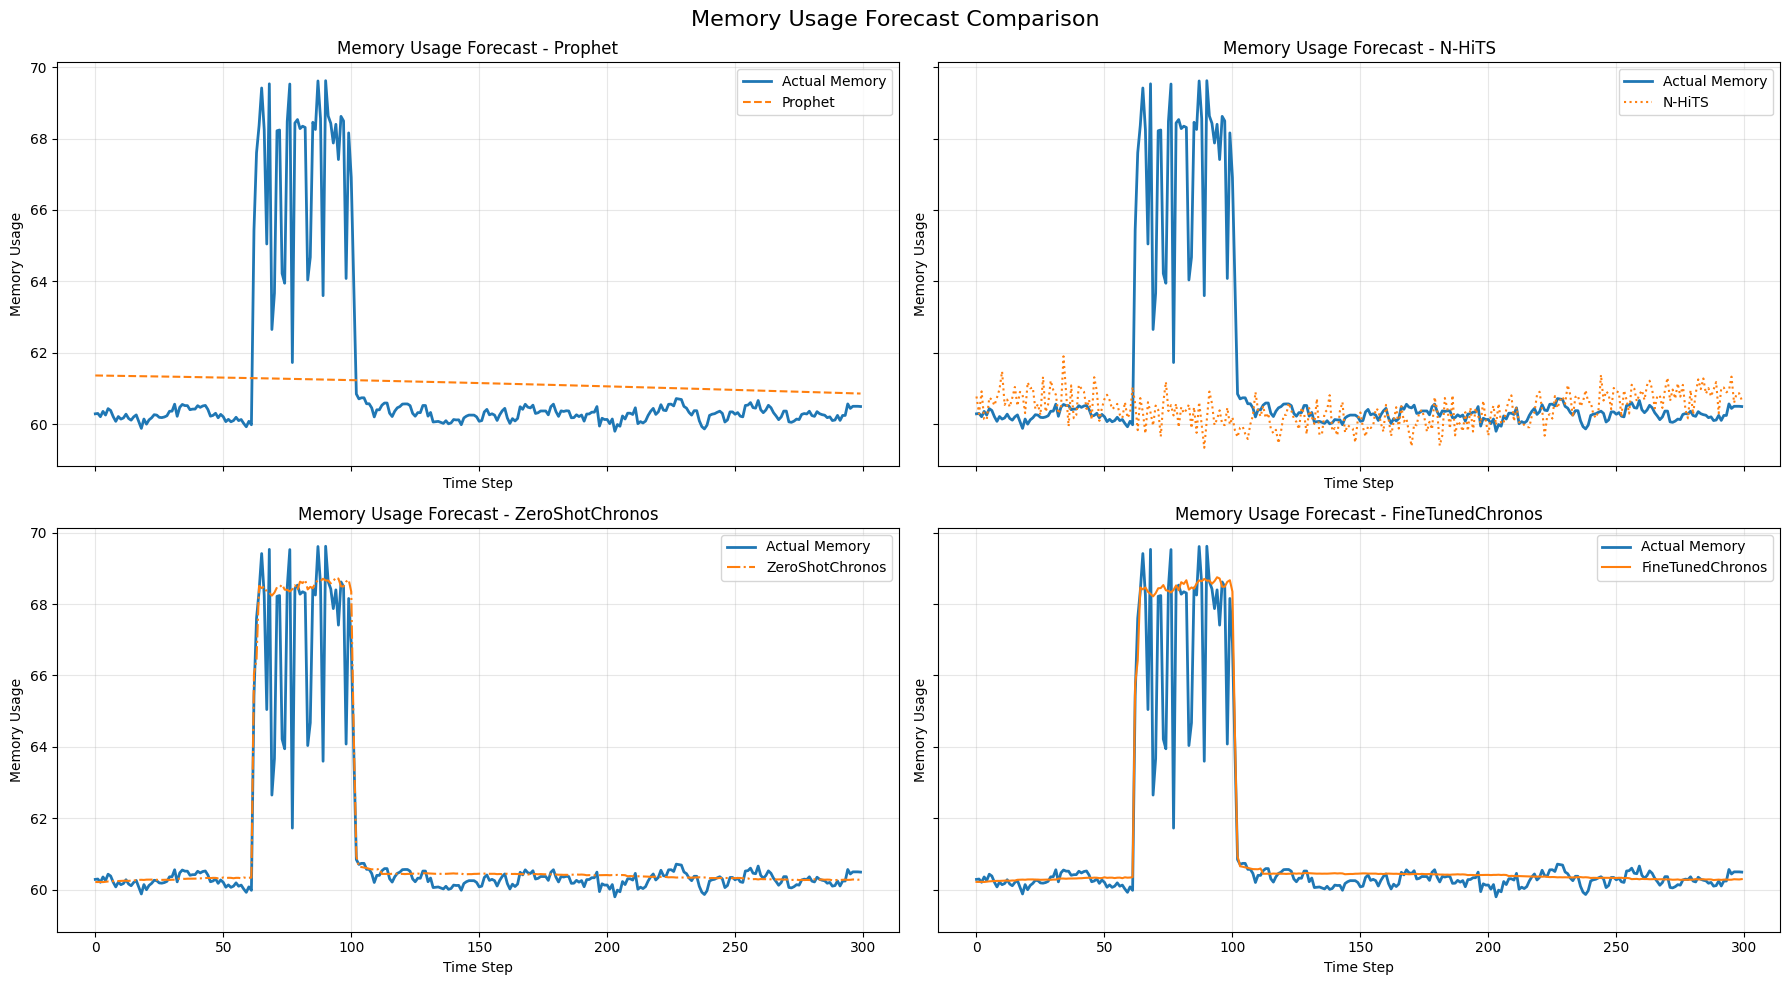

In [33]:
import matplotlib.pyplot as plt

x = range(300)

models = [
    ("Prophet", y_pred_prophet_mem, "--"),
    ("N-HiTS", y_pred_nhits_mem, ":"),
    ("ZeroShotChronos", y_pred_zeroshot_chronos_mem, "-."),
    ("FineTunedChronos", y_pred_finetuned_chronos_mem, "-"),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (model_name, y_pred, linestyle) in zip(axes, models):
    ax.plot(x, y_true_mem, label="Actual Memory", linewidth=2)
    ax.plot(x, y_pred, label=model_name, linestyle=linestyle)

    ax.set_title(f"Memory Usage Forecast - {model_name}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Memory Usage")
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("Memory Usage Forecast Comparison", fontsize=16)
plt.tight_layout()
plt.show()

For CPU

In [30]:
y_train_cpu = train_df['CPU Usage']
y_true_cpu = test_df['CPU Usage']
y_pred_prophet_cpu = forecast_cpu['yhat'].iloc[-300:]
y_pred_nhits_cpu = cpu_preds
y_pred_finetuned_chronos_cpu = finetuned_chronos_cpu_pred['mean']
y_pred_zeroshot_chronos_cpu = zeroshot_chronos_cpu_pred['mean']

In [31]:
eval_cpu = pd.DataFrame({
    'Model': ['Prophet', 'N-HiTS', 'ZeroShot_Chronos', 'FineTuned_Chronos'],
    'RMSE': [
        rmse(y_true_cpu, y_pred_prophet_cpu),
        rmse(y_true_cpu, y_pred_nhits_cpu),
        rmse(y_true_cpu, y_pred_zeroshot_chronos_cpu),
        rmse(y_true_cpu, y_pred_finetuned_chronos_cpu)
    ],
    'MASE': [
        mase(y_train_cpu, y_true_cpu, y_pred_prophet_cpu),
        mase(y_train_cpu, y_true_cpu, y_pred_nhits_cpu),
        mase(y_train_cpu, y_true_cpu, y_pred_zeroshot_chronos_cpu),
        mase(y_train_cpu, y_true_cpu, y_pred_finetuned_chronos_cpu),
    ]
})

display(eval_cpu)

,Model,RMSE,MASE
0,Prophet,1.326839,0.632892
1,N-HiTS,1.292627,0.607072
2,ZeroShot_Chronos,1.092927,0.463261
3,FineTuned_Chronos,1.091124,0.461230


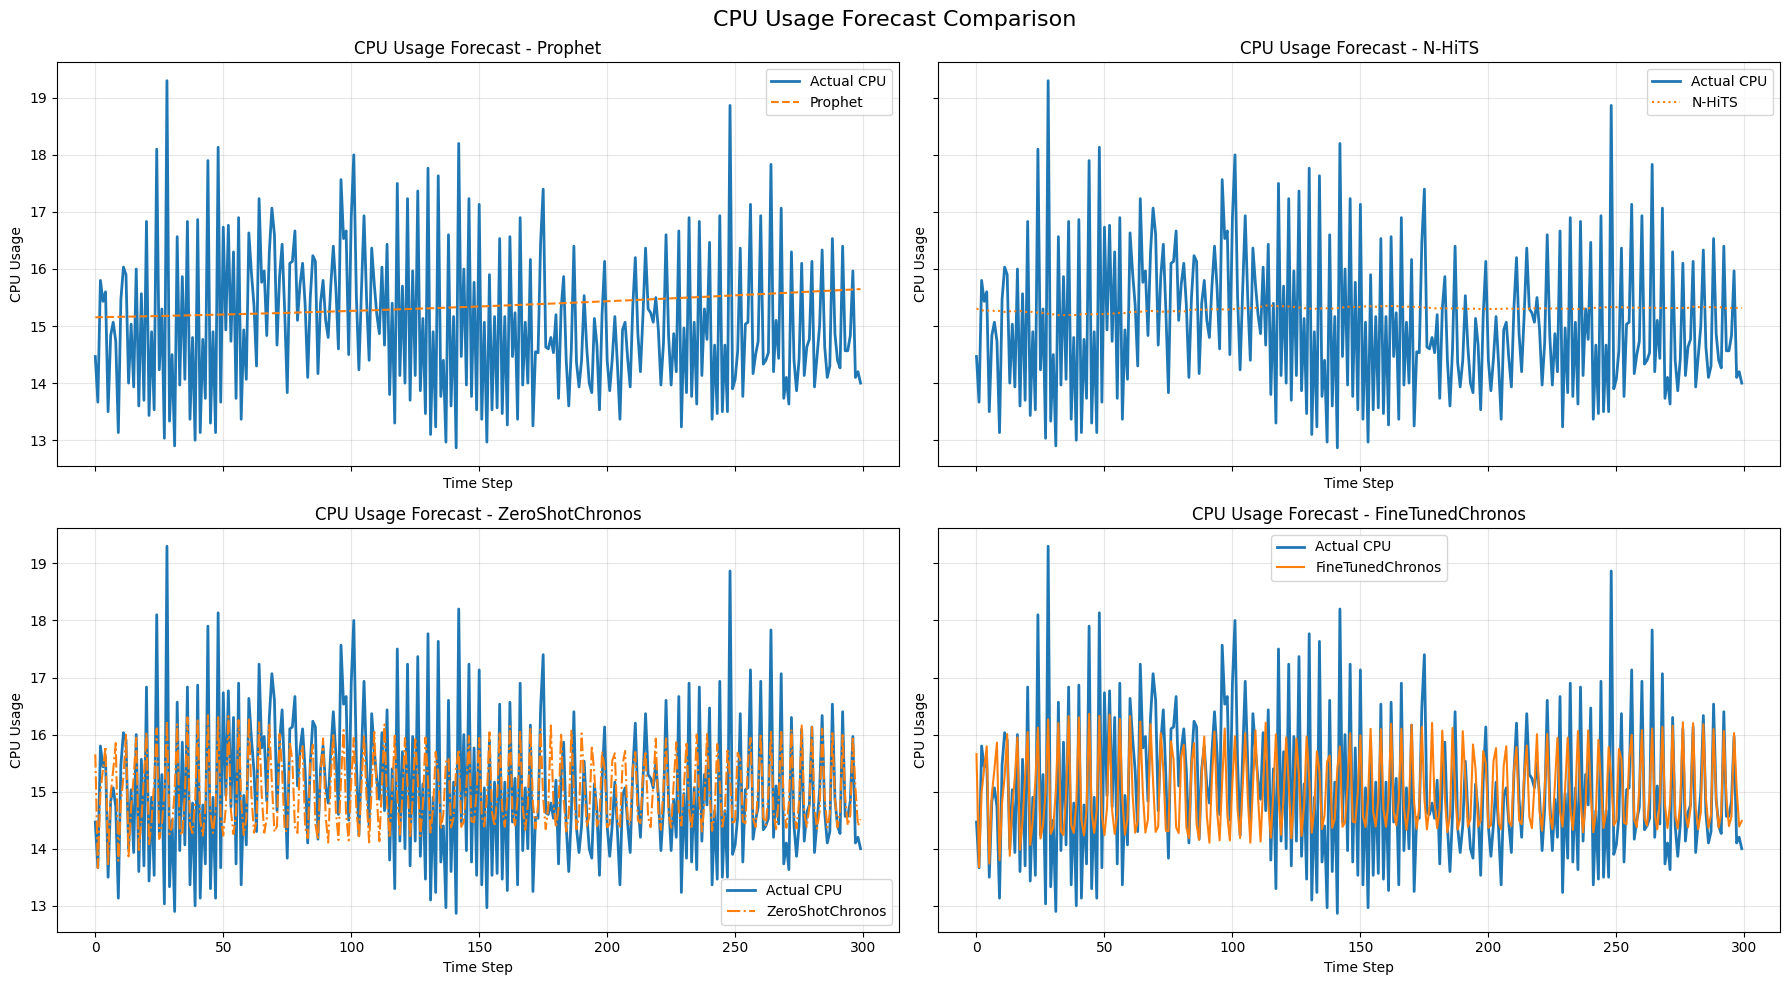

In [34]:
import matplotlib.pyplot as plt

x = range(300)

models = [
    ("Prophet", y_pred_prophet_cpu, "--"),
    ("N-HiTS", y_pred_nhits_cpu, ":"),
    ("ZeroShotChronos", y_pred_zeroshot_chronos_cpu, "-."),
    ("FineTunedChronos", y_pred_finetuned_chronos_cpu, "-"),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (model_name, y_pred, linestyle) in zip(axes, models):
    ax.plot(x, y_true_cpu, label="Actual CPU", linewidth=2)
    ax.plot(x, y_pred, label=model_name, linestyle=linestyle)

    ax.set_title(f"CPU Usage Forecast - {model_name}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("CPU Usage")
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("CPU Usage Forecast Comparison", fontsize=16)
plt.tight_layout()
plt.show()